<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
# (!nvidia-smi only works on machines with an NVIDIA driver, so check with PyTorch instead)
import torch
print(f"CUDA GPU available: {torch.cuda.is_available()}")

CUDA GPU available: False


In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.14.0+cpu


'cpu'

## 1. What are 3 areas in industry where computer vision is currently being used?

**Trả lời:**

1. **Xe tự lái / hỗ trợ lái xe (ADAS)**: camera trên xe (ví dụ Tesla, Waymo) dùng mô hình thị giác máy tính để nhận diện làn đường, biển báo, người đi bộ và các phương tiện khác theo thời gian thực.
2. **Y tế – chẩn đoán hình ảnh**: mô hình CNN phân tích ảnh X-quang, CT, MRI để phát hiện khối u, viêm phổi, bệnh võng mạc do tiểu đường... giúp bác sĩ chẩn đoán nhanh và chính xác hơn.
3. **Sản xuất công nghiệp – kiểm tra chất lượng**: camera trên dây chuyền phát hiện sản phẩm lỗi (vết nứt, trầy xước, lắp ráp sai) tự động thay cho kiểm tra thủ công.

(Ngoài ra còn có: nhận diện khuôn mặt để mở khóa điện thoại / chấm công, bán lẻ không thu ngân như Amazon Go, nông nghiệp thông minh phát hiện sâu bệnh qua ảnh drone...)

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

**Trả lời:**

**Overfitting (quá khớp)** xảy ra khi mô hình học quá kỹ dữ liệu huấn luyện – kể cả nhiễu và các chi tiết ngẫu nhiên – nên đạt kết quả rất tốt trên tập train nhưng lại dự đoán kém trên dữ liệu mới (tập test), tức là mô hình *ghi nhớ* thay vì *tổng quát hóa*.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

**Trả lời:** ba cách chống overfitting:

1. **Thêm dữ liệu / tăng cường dữ liệu (data augmentation)**: càng nhiều mẫu đa dạng thì mô hình càng khó ghi nhớ từng mẫu; với ảnh có thể lật, xoay, cắt, đổi màu ngẫu nhiên để tạo thêm biến thể từ dữ liệu sẵn có.
2. **Regularization (điều chuẩn) như Dropout, L2/weight decay**: Dropout tắt ngẫu nhiên một số nơ-ron khi huấn luyện, còn weight decay phạt các trọng số lớn, cả hai đều buộc mô hình học các đặc trưng đơn giản, tổng quát hơn.
3. **Early stopping (dừng sớm)**: theo dõi loss trên tập validation và dừng huấn luyện khi loss này bắt đầu tăng trở lại, trước khi mô hình kịp học thuộc nhiễu của tập train.

(Các cách khác: đơn giản hóa mô hình – ít layer/ít tham số hơn, transfer learning, batch normalization, cross-validation.)

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

**Ghi chú:** phần này là hoạt động tương tác trên website [CNN Explainer](https://poloclub.github.io/cnn-explainer/) – bạn cần tự mở trang và upload ảnh. Tóm tắt những gì trang minh họa ở từng lớp của mô hình TinyVGG:

* **Input (3 kênh R, G, B)**: ảnh được đổi kích thước về 64x64 và tách thành 3 ma trận màu.
* **Conv2d**: mỗi bộ lọc (kernel 3x3) trượt trên ảnh, nhân từng phần tử rồi cộng lại (+ bias) để tạo *feature map*; các lớp conv đầu phát hiện đặc trưng đơn giản (cạnh, màu sắc), các lớp sau kết hợp thành đặc trưng phức tạp hơn (hình dạng, bộ phận của vật thể).
* **ReLU**: thay các giá trị âm bằng 0, giữ lại vùng được kích hoạt mạnh, tạo tính phi tuyến.
* **MaxPool2d**: lấy giá trị lớn nhất trong mỗi ô 2x2, giảm một nửa chiều cao/rộng của feature map, giữ lại đặc trưng nổi bật nhất và giảm số phép tính.
* **Flatten + Linear + Softmax**: feature map cuối được duỗi thành vector, lớp tuyến tính cho ra 10 logits, softmax đổi logits thành xác suất cho từng lớp; lớp có xác suất cao nhất là dự đoán.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
import torchvision
from torchvision import datasets, transforms

# Get the MNIST train dataset
train_data = datasets.MNIST(root="data",
                            train=True,
                            download=True,
                            transform=transforms.ToTensor()) # do we want to transform the data as we download it?

# Get the MNIST test dataset
test_data = datasets.MNIST(root="data",
                           train=False,
                           download=True,
                           transform=transforms.ToTensor())

train_data, test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
# Data is in tuple form (image, label)
img = train_data[0][0]
label = train_data[0][1]
print(f"Image:\n {img.shape}")
print(f"Label:\n {label}")

# Get the class names from the dataset
class_names = train_data.classes
class_names

Image:
 torch.Size([1, 28, 28])
Label:
 5


['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 6. Visualize at least 5 different samples of the MNIST training dataset.

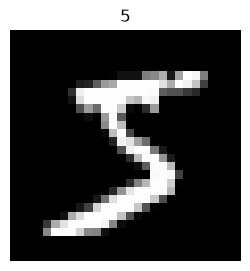

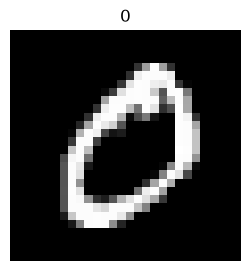

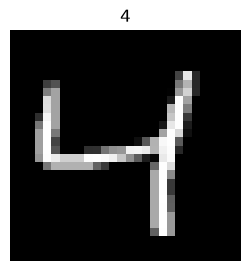

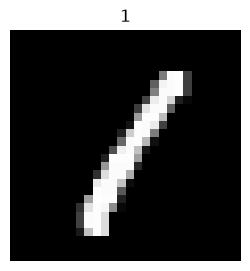

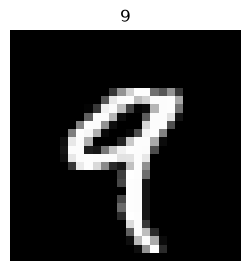

In [6]:
import matplotlib.pyplot as plt

for i in range(5):
  img = train_data[i][0]
  label = train_data[i][1]
  plt.figure(figsize=(3, 3))
  plt.imshow(img.squeeze(), cmap="gray") # [1, 28, 28] -> [28, 28]
  plt.title(label)
  plt.axis(False);

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [7]:
# Create train dataloader
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x187bcd0e900>,
 <torch.utils.data.dataloader.DataLoader at 0x187bce565d0>)

In [8]:
for sample in next(iter(train_dataloader)):
  print(sample.shape)

len(train_dataloader), len(test_dataloader)

torch.Size([32, 1, 28, 28])
torch.Size([32])


(1875, 313)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [9]:
from torch import nn

class MNIST_model(torch.nn.Module):
  """Model capable of predicting on MNIST dataset (TinyVGG from CNN Explainer).
  """
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        # 28x28 -> MaxPool -> 14x14 -> MaxPool -> 7x7
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x

torch.manual_seed(42)
model = MNIST_model(input_shape=1,
                    hidden_units=10,
                    output_shape=len(class_names)).to(device)
model

MNIST_model(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [10]:
# Check out the model with a dummy forward pass
dummy_x = torch.rand(size=(1, 28, 28)).unsqueeze(dim=0).to(device)
model(dummy_x).shape

torch.Size([1, 10])

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [11]:
from timeit import default_timer as timer
from tqdm.auto import tqdm

def train_model(model, train_dataloader, test_dataloader, epochs, device):
  """Train + evaluate a model for a number of epochs on a target device."""
  model.to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

  for epoch in tqdm(range(epochs)):
    ### Training
    train_loss = 0
    model.train()
    for batch, (X, y) in enumerate(train_dataloader):
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      loss = loss_fn(y_pred, y)
      train_loss += loss.item()
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    train_loss /= len(train_dataloader)

    ### Testing
    test_loss, test_correct = 0, 0
    model.eval()
    with torch.inference_mode():
      for X_test, y_test in test_dataloader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        test_pred = model(X_test)
        test_loss += loss_fn(test_pred, y_test).item()
        test_correct += (test_pred.argmax(dim=1) == y_test).sum().item()
    test_loss /= len(test_dataloader)
    test_acc = test_correct / len(test_dataloader.dataset) * 100

    print(f"Epoch: {epoch} | Train loss: {train_loss:.3f} | Test loss: {test_loss:.3f} | Test acc: {test_acc:.2f}%")
  return model

In [12]:
# Train on CPU
torch.manual_seed(42)
model_cpu = MNIST_model(input_shape=1,
                        hidden_units=10,
                        output_shape=10)

start_time_cpu = timer()
model_cpu = train_model(model_cpu, train_dataloader, test_dataloader, epochs=5, device="cpu")
end_time_cpu = timer()
total_time_cpu = end_time_cpu - start_time_cpu
print(f"Train time on CPU: {total_time_cpu:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:32<02:11, 32.78s/it]

Epoch: 0 | Train loss: 0.265 | Test loss: 0.080 | Test acc: 97.37%


 40%|████      | 2/5 [01:11<01:48, 36.29s/it]

Epoch: 1 | Train loss: 0.069 | Test loss: 0.042 | Test acc: 98.58%


...

 80%|████████  | 4/5 [02:41<00:42, 42.11s/it]

Epoch: 3 | Train loss: 0.044 | Test loss: 0.040 | Test acc: 98.68%


100%|██████████| 5/5 [03:22<00:00, 41.81s/it]

100%|██████████| 5/5 [03:22<00:00, 40.48s/it]

Epoch: 4 | Train loss: 0.039 | Test loss: 0.033 | Test acc: 98.87%
Train time on CPU: 202.402 seconds


In [13]:
# Train on GPU
# This machine has no CUDA GPU, so this cell only runs when one is available.
if torch.cuda.is_available():
  torch.manual_seed(42)
  model_gpu = MNIST_model(input_shape=1,
                          hidden_units=10,
                          output_shape=10)

  start_time_gpu = timer()
  model_gpu = train_model(model_gpu, train_dataloader, test_dataloader, epochs=5, device="cuda")
  end_time_gpu = timer()
  total_time_gpu = end_time_gpu - start_time_gpu
  print(f"Train time on GPU: {total_time_gpu:.3f} seconds")
  print(f"GPU speedup: {total_time_cpu/total_time_gpu:.2f}x")
else:
  print("[INFO] No CUDA GPU found, skipping GPU training (the code above runs as-is on a GPU machine).")

[INFO] No CUDA GPU found, skipping GPU training (the code above runs as-is on a GPU machine).


**Nhận xét:** Máy thực hiện bài này không có GPU NVIDIA nên chỉ đo được thời gian trên CPU (xem kết quả ô trên).
Với mô hình nhỏ như TinyVGG và ảnh 28x28, GPU thường chỉ nhanh hơn CPU vài lần, vì phần lớn thời gian dành cho việc
nạp dữ liệu và chép dữ liệu CPU → GPU chứ không phải tính toán; với mô hình và batch lớn hơn thì khoảng cách sẽ rõ rệt hơn nhiều.

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

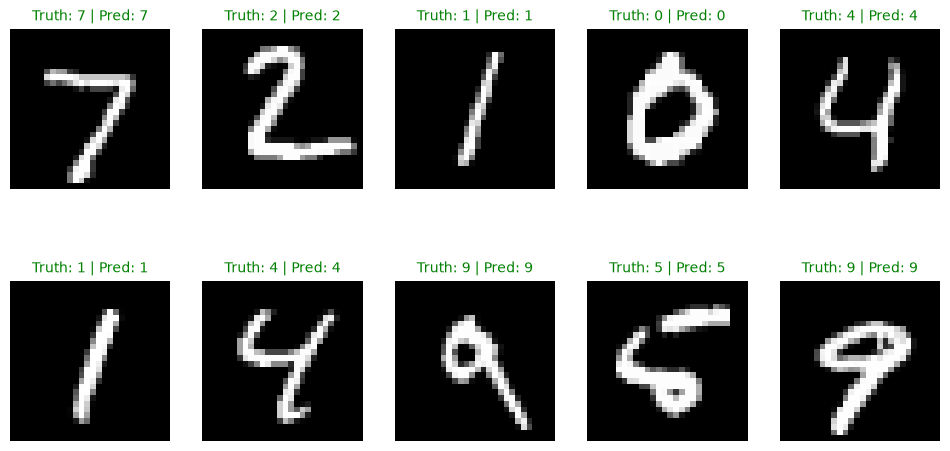

In [14]:
# Make predictions with the trained model (the CPU one)
model = model_cpu
model.eval()

plt.figure(figsize=(12, 6))
for i in range(10):
  img, label = test_data[i]
  with torch.inference_mode():
    pred_logits = model(img.unsqueeze(dim=0).to(device))
  pred_label = pred_logits.argmax(dim=1).item()

  plt.subplot(2, 5, i+1)
  plt.imshow(img.squeeze(), cmap="gray")
  # Green title if correct, red if wrong
  color = "g" if pred_label == label else "r"
  plt.title(f"Truth: {label} | Pred: {pred_label}", c=color, fontsize=10)
  plt.axis(False);

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [15]:
# See if torchmetrics exists, if not, install it
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
  %pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.25.0


In [16]:
# Make predictions across all test data
model.eval()
y_preds = []
with torch.inference_mode():
  for X, y in tqdm(test_dataloader):
    X, y = X.to(device), y.to(device)
    y_pred_logits = model(X)
    y_pred_labels = torch.argmax(torch.softmax(y_pred_logits, dim=1), dim=1)
    y_preds.append(y_pred_labels.cpu())

y_preds = torch.cat(y_preds)
len(y_preds), y_preds[:10]

  0%|          | 0/313 [00:00<?, ?it/s]

  4%|▍         | 13/313 [00:00<00:02, 117.86it/s]

  8%|▊         | 25/313 [00:00<00:02, 114.68it/s]

 12%|█▏        | 37/313 [00:00<00:02, 116.05it/s]

 16%|█▌        | 49/313 [00:00<00:02, 113.53it/s]

...

 90%|████████▉ | 281/313 [00:02<00:00, 111.22it/s]

 94%|█████████▍| 294/313 [00:02<00:00, 114.38it/s]

 98%|█████████▊| 306/313 [00:02<00:00, 111.45it/s]

100%|██████████| 313/313 [00:02<00:00, 107.90it/s]

(10000, tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9]))

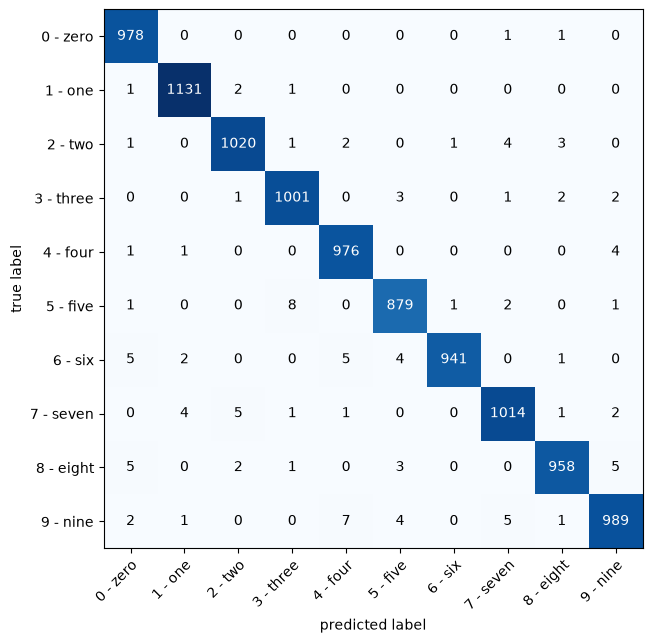

In [17]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion matrix
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_preds,
                         target=test_data.targets)

# Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [18]:
torch.manual_seed(42)
random_tensor = torch.rand([1, 3, 64, 64])
print(f"Input shape: {random_tensor.shape}")

# Try different kernel sizes (stride=1, padding=0)
for kernel_size in [1, 3, 5, 10, 32, 64]:
  conv_layer = nn.Conv2d(in_channels=3,
                         out_channels=64,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=0)
  print(f"kernel_size={kernel_size:>2} -> output shape: {conv_layer(random_tensor).shape}")

Input shape: torch.Size([1, 3, 64, 64])
kernel_size= 1 -> output shape: torch.Size([1, 64, 64, 64])
kernel_size= 3 -> output shape: torch.Size([1, 64, 62, 62])
kernel_size= 5 -> output shape: torch.Size([1, 64, 60, 60])
kernel_size=10 -> output shape: torch.Size([1, 64, 55, 55])
kernel_size=32 -> output shape: torch.Size([1, 64, 33, 33])
kernel_size=64 -> output shape: torch.Size([1, 64, 1, 1])


In [19]:
# Stride and padding also change the output size
for kernel_size, stride, padding in [(3, 1, 1), (3, 2, 1), (5, 1, 2), (5, 2, 0)]:
  conv_layer = nn.Conv2d(in_channels=3,
                         out_channels=64,
                         kernel_size=kernel_size,
                         stride=stride,
                         padding=padding)
  print(f"kernel_size={kernel_size}, stride={stride}, padding={padding} -> output shape: {conv_layer(random_tensor).shape}")

kernel_size=3, stride=1, padding=1 -> output shape: torch.Size([1, 64, 64, 64])
kernel_size=3, stride=2, padding=1 -> output shape: torch.Size([1, 64, 32, 32])
kernel_size=5, stride=1, padding=2 -> output shape: torch.Size([1, 64, 64, 64])
kernel_size=5, stride=2, padding=0 -> output shape: torch.Size([1, 64, 30, 30])


**Nhận xét:** kích thước đầu ra theo mỗi chiều được tính theo công thức

$$\text{out} = \left\lfloor \frac{\text{in} - \text{kernel\_size} + 2 \times \text{padding}}{\text{stride}} \right\rfloor + 1$$

* Khi **`kernel_size` tăng** (với padding = 0) thì feature map đầu ra **nhỏ lại**: kernel 3 → 62x62, kernel 10 → 55x55, kernel 64 (bằng kích thước ảnh) → chỉ còn 1x1. Kernel lớn "nhìn" được vùng rộng hơn của ảnh nhưng có nhiều tham số hơn.
* Khi **`kernel_size` giảm** thì đầu ra lớn hơn; kernel 1x1 giữ nguyên 64x64 (chỉ trộn các kênh màu với nhau).
* Có thể giữ nguyên kích thước bằng cách thêm `padding = (kernel_size - 1) / 2` (ví dụ kernel 3 + padding 1), còn `stride = 2` sẽ giảm kích thước đi khoảng một nửa.
* Số kênh đầu ra luôn bằng `out_channels` (64), không phụ thuộc vào `kernel_size`.

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [20]:
# Download FashionMNIST train & test
from torchvision import datasets
from torchvision import transforms

fashion_mnist_train = datasets.FashionMNIST(root="data",
                                            download=True,
                                            train=True,
                                            transform=transforms.ToTensor())

fashion_mnist_test = datasets.FashionMNIST(root="data",
                                           train=False,
                                           download=True,
                                           transform=transforms.ToTensor())

fashion_mnist_class_names = fashion_mnist_train.classes
len(fashion_mnist_train), len(fashion_mnist_test), fashion_mnist_class_names

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<02:45, 159kB/s]

  0%|          | 65.5k/26.4M [00:00<02:45, 159kB/s]

  0%|          | 98.3k/26.4M [00:00<02:43, 161kB/s]

  1%|          | 229k/26.4M [00:00<01:14, 351kB/s] 

...

 54%|█████▍    | 2.39M/4.42M [00:01<00:00, 2.86MB/s]

100%|██████████| 4.42M/4.42M [00:01<00:00, 2.66MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]

(60000,
 10000,
 ['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'])

In [21]:
# Turn FashionMNIST datasets into dataloaders
from torch.utils.data import DataLoader

fashion_mnist_train_dataloader = DataLoader(fashion_mnist_train,
                                            batch_size=32,
                                            shuffle=True)

fashion_mnist_test_dataloader = DataLoader(fashion_mnist_test,
                                           batch_size=32,
                                           shuffle=False)

len(fashion_mnist_train_dataloader), len(fashion_mnist_test_dataloader)

(1875, 313)

In [22]:
# model_2 from notebook 03 is the same TinyVGG architecture (1 input channel, 10 classes)
torch.manual_seed(42)
model_2 = MNIST_model(input_shape=1,
                      hidden_units=10,
                      output_shape=len(fashion_mnist_class_names)).to(device)

model_2 = train_model(model_2,
                      fashion_mnist_train_dataloader,
                      fashion_mnist_test_dataloader,
                      epochs=5,
                      device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:40<02:41, 40.38s/it]

Epoch: 0 | Train loss: 0.578 | Test loss: 0.395 | Test acc: 85.58%


 40%|████      | 2/5 [01:19<01:59, 39.83s/it]

Epoch: 1 | Train loss: 0.355 | Test loss: 0.368 | Test acc: 86.29%


...

 80%|████████  | 4/5 [02:29<00:35, 35.80s/it]

Epoch: 3 | Train loss: 0.296 | Test loss: 0.311 | Test acc: 88.61%


100%|██████████| 5/5 [02:56<00:00, 32.46s/it]

100%|██████████| 5/5 [02:56<00:00, 35.22s/it]

Epoch: 4 | Train loss: 0.282 | Test loss: 0.300 | Test acc: 89.19%


In [23]:
# Make predictions with trained model_2 on the whole test set
test_preds = []
model_2.eval()
with torch.inference_mode():
  for X_test, y_test in tqdm(fashion_mnist_test_dataloader):
    y_logits = model_2(X_test.to(device))
    y_pred_labels = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
    test_preds.append(y_pred_labels.cpu())

test_preds = torch.cat(test_preds)
test_preds[:10], len(test_preds)

  0%|          | 0/313 [00:00<?, ?it/s]

  5%|▌         | 17/313 [00:00<00:01, 163.15it/s]

 11%|█         | 35/313 [00:00<00:01, 168.18it/s]

 17%|█▋        | 52/313 [00:00<00:01, 167.58it/s]

 22%|██▏       | 69/313 [00:00<00:01, 168.27it/s]

...

 88%|████████▊ | 274/313 [00:01<00:00, 159.56it/s]

 93%|█████████▎| 290/313 [00:01<00:00, 156.81it/s]

 98%|█████████▊| 307/313 [00:01<00:00, 160.52it/s]

100%|██████████| 313/313 [00:01<00:00, 163.79it/s]

(tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]), 10000)

In [24]:
# Get wrong prediction indexes
import numpy as np
wrong_pred_indexes = np.where(test_preds != fashion_mnist_test.targets)[0]
print(f"Number of wrong predictions: {len(wrong_pred_indexes)} / {len(test_preds)}")

Number of wrong predictions: 1081 / 10000


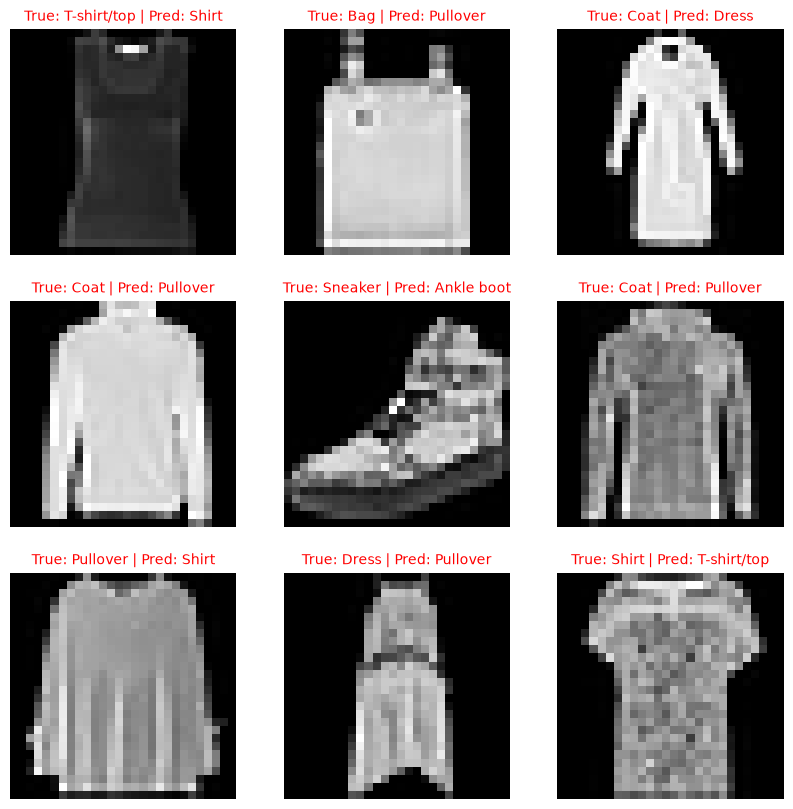

In [25]:
# Select random 9 wrong predictions and plot them
import random
random.seed(42)
random_selection = random.sample(list(wrong_pred_indexes), k=9)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_selection):
  # Get true and pred labels
  true_label = fashion_mnist_class_names[fashion_mnist_test[idx][1]]
  pred_label = fashion_mnist_class_names[test_preds[idx]]

  # Plot the wrong prediction with its original label
  plt.subplot(3, 3, i+1)
  plt.imshow(fashion_mnist_test[idx][0].squeeze(), cmap="gray")
  plt.title(f"True: {true_label} | Pred: {pred_label}", c="r", fontsize=10)
  plt.axis(False);

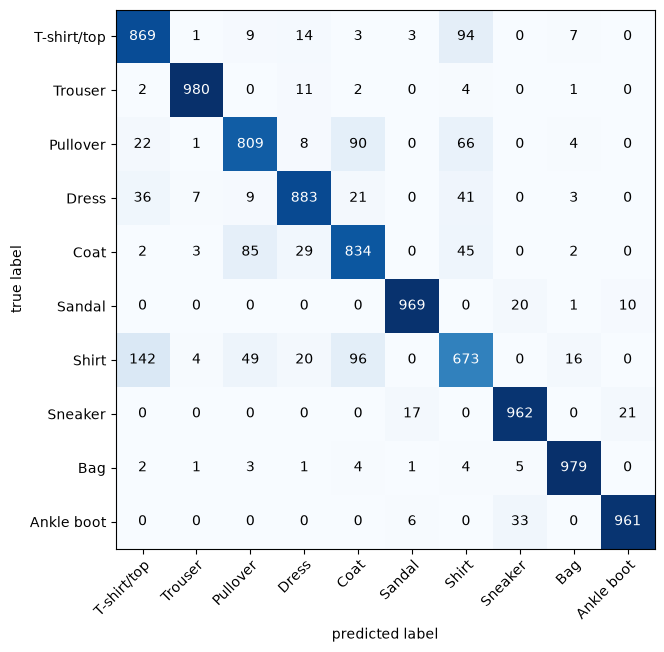

In [26]:
# Which classes get confused the most? (confusion matrix on FashionMNIST)
confmat = ConfusionMatrix(task="multiclass", num_classes=len(fashion_mnist_class_names))
confmat_tensor = confmat(preds=test_preds, target=fashion_mnist_test.targets)

fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),
                                class_names=fashion_mnist_class_names,
                                figsize=(10, 7))